## Calculate the Lyapunov spectrum of ECA rule 150

As a sanity check, we below inspect the Lyapunov profile and spectrum for rule 150. We will generalise this to other ECAs and to LLNAs in the next document.

### _Tracing a single defect_
The Jacobian associated with an ECA of $N$ cells governed by rule 150 is
$$
\mathbf{J}(\mathbf{s}^t) = \mathbf{J} = \begin{pmatrix}
1 & 1 & 0 & \ldots & 0 & 0 & 1 \\
1 & 1 & 1 & \ldots & 0 & 0 & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
0 & 0 & 0 & \ldots & 1 & 1 & 1 \\
1 & 0 & 0 & \ldots & 0 & 1 & 1
\end{pmatrix}.
$$
A single perturbation in cell $i=1$ is written as
$$
\delta\mathbf{s}_1 = \begin{pmatrix}
1\\
0\\
\vdots \\
0
\end{pmatrix},
$$
so the propagation of this perturbation in tangent space is
$$
\delta \mathbf{s}^t_1 = \mathbf{J}^t \delta\mathbf{s}_1.
$$
This column vector can be plotted in its entirety to show how many times each cell has been affected, in what is known as the _Lyapunov profile_. However, the _relevant_ Lyapunov exponent is simply the normalised logarithm of the maximal value of this column vector, i.e.
$$
\lambda_i = \lim_{t\rightarrow\infty}\frac{1}{t}\ln\left({\max_j\{\left(\mathbf{J}^t \delta\mathbf{s}_i\right)_j\}}\right).
$$
This value indicates the largest possible growth in defect due to an initial perturbation. There may be other places where the defect has an impact, but only the largest value will determine whether a system is chaotic or not.

### _Tracing all unit defects simultaneously_

One could iteratively calculate the Lyapunov exponent $\lambda_i$ for each defect $\delta\vec{x}_i$ individually, but that is algebraically identical to just appending all initial defects together in what you could call a perturbation sphere $\mathbf{Y}^0$:
$$
\mathbf{Y}^0 = \begin{pmatrix}
\delta\mathbf{s}_1 & \delta\mathbf{s}_2 & \cdots & \delta\mathbf{s}_N
\end{pmatrix}  = \mathbf{I}_N,
$$
the unit diagonal matrix (identity matrix). For rule 150, this again results in $\mathbf{Y}^t = \mathbf{J}^t \mathbf{Y}^0$. The set of Lyapunov exponents is then simply related to the maximum in each column of $\mathbf{Y}^t$.

### _Tracing the perturbation sphere_

We can also trace all defects at the same time, but in a slightly more sophisticated way (**how though?**) that arguably has a better geometric interpretation.

We are now interested in the _singular values_ of matrix $Y^t$, which is identical to the positive roots of the eigenvalues of the positive definite matrix $\Gamma^t = Y^t \times (Y^t)^T$. The singular values of $Y^t$ are geometrically interpreted as the lengths of the semi-axes of the ellipsoid represented by $Y^t$ (evolved from the initial unit sphere $Y^0$). The corresponding singular vectors represent the directions of this ellipsoid's axes (but we will not go into that here). So:
$$
\Gamma^t \vec{v}_k = \sigma_k^2 \vec{v}_k
$$
for $k \in \{0, \ldots, N-1\}$. Here we use index $k$ rather than $i$, because there is no longer a clear relationship between a defect node and a singular value due to rotations. Note again that $\sigma_k^2$ will indeed always be positive, because $\Gamma$ has been constructed to be positive definite. The final step is then to just plot the distribution of all $\{\sigma_k\}$ (typically in a histogram), quantifying how the unit sphere is being stretched. The Lyapunov exponents are then defined as
$$
\Lambda_k = \lim_{t\rightarrow\infty}\frac{1}{t}\ln{\sigma_k}
$$
Note also that, if the Jacobian is symmetric (as is the case for rule 150), the singular values are identical to the absolute values of the eigenvalues of $\mathbf{J}$.

The advantage of this approach is that it gives a more honest quantification of the _overall_ effect of initial perturbations. A disadvantage is that it is now generally unclear which perturbations are associated with which initial defect, i.e. one cannot distinguish between the effect of perturbing node $i$ versus node $j$. Given their homogeneity, this is not a big deal for ECAs. For NAs, however, individual nodes will differ in terms of network properties (such as degree), so it may be useful to document the relationship between perturbing one node versus the other.

This response of ChatGPT is quite insightful:

>**Geometrical Interpretation**
>The geometrical interpretation of the singular values lies in how the matrix $\mathbf{A}$ transforms vectors from one space to another:
>
>- Unit Sphere Transformation:
>
>Consider the unit sphere in $R_n$. This is the set of all vectors $\mathbf{x}$ such that $||\mathbf{x}|| = 1$. When the matrix $\mathbf{A}$ is applied to this unit sphere, it transforms it into an ellipsoid in $R_m$.
>
>- Axes of the Ellipsoid:
>
>The singular values of $\mathbf{A}$, denoted as $\{\sigma_1, \sigma_2, \ldots, \sigma_r\}$ (where $r$ is the rank of $\mathbf{A}$) represent the lengths of the semi-axes of this ellipsoid. The vectors in $\mathbf{V}$ (right singular vectors) determine the directions of the original space (domain) that get mapped to the principal axes of the ellipsoid in the transformed space. The vectors in $\mathbf{U}$ determine the directions in the transformed space (codomain) corresponding to the principal axes of the ellipsoid.
>
>- Stretching and Compression:
>
>Each singular value $\sigma_i$ indicates how much the matrix $\mathbf{A}$ stretches or compresses vectors along the direction of the $i$-th right singular vector.
If a singular value $\sigma_i$ is much larger than the others, it means that the matrix $\mathbf{A}$ significantly stretches vectors along the corresponding direction.
Conversely, if a singular value is much smaller (but non-zero), it indicates compression along that direction.
>Zero singular values indicate directions that are collapsed to zero, corresponding to the null space of $\mathbf{A}$

See also [this link](https://towardsdatascience.com/svd-a-geometric-view-point-cfc0c689bdc0) for another geometric explanation of the SVD.

**Question** What would be a good interpretation of the singular vectors in the case of ECAs?

We now look at the various interpretations, and apply it to a number of ECAs.

In [4]:
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt

import scipy.linalg

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

from src.datasets import NetworksDataset
from src.automata import LLNA
from src.simulation import *
from src.analysis import jacobian, jacobian_ECA, calculate_Yt, lyapunov_spectrum

%load_ext autoreload
%autoreload 2

# The Lyapunov profile: a single defect

In [5]:
# number of cells
N = 501
rule = 150
states = np.ones(N)

J = jacobian_ECA(rule=rule, states=states, return_next=False)

defect_id = N//2
delta_xi = np.zeros(N, dtype=np.float64)
delta_xi[defect_id] = 1

T = N//2
ts = np.arange(1,T)
tangent_defects = []
lambdas_i = []

Jt = J.copy()
for t in ts:
    # update defect
    print(f"t={t}", end='\r')
    tangent_defect = Jt.dot(delta_xi)
    lambda_i = np.log(np.max(tangent_defect)) / t
    lambdas_i += [lambda_i]
    tangent_defects += [tangent_defect]
    Jt = J.dot(Jt)

Text(0.5, 1.0, 'Evolution of defect profile')

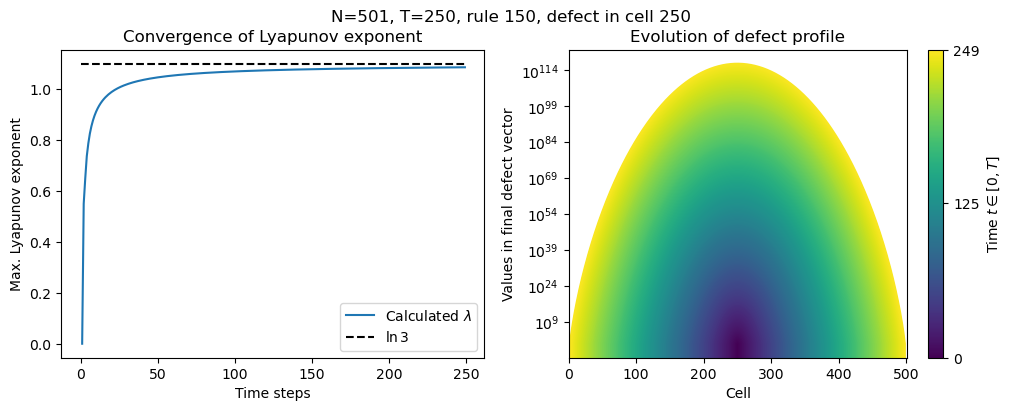

In [22]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,4))

ax1.plot(ts, lambdas_i, label=f'Calculated $\\lambda$')
ax1.plot([0, np.max(ts)], [np.log(3), np.log(3)], 'k--', label=f'$\ln{3}$')
ax1.legend()
ax1.set_ylabel("Max. Lyapunov exponent")
ax1.set_xlabel("Time steps")

# Generate a colormap
cmap = plt.get_cmap('viridis', T)

for j, td in enumerate(np.array(tangent_defects)[:-1]):
    ax2.plot(td, c=cmap(j))
    ax2.set_yscale('log')
    ax2.set_ylabel("Values in final defect vector")
    ax2.set_xlabel("Cell")
    ax2.set_xlim([0, N])

# Add color bar
norm = plt.Normalize(0, T - 1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax2, ticks=[0, T//2, T-1])
cbar.set_label(f'Time $t \in [0, T]$')

# add titles
fig.suptitle(f"N={N}, T={T}, rule 150, defect in cell {defect_id}")
ax1.set_title("Convergence of Lyapunov exponent")
ax2.set_title("Evolution of defect profile")

**Interpretation of the figures above**

In the figure on the lefthand side, we find the value of $\lambda_i = \lim_{t\rightarrow\infty}\frac{1}{t}\ln\left({\max_j\{\left(\mathbf{J}^t \delta\mathbf{s}_i\right)_j\}}\right)$, i.e. the normalised logarithm of the largest defect in tangent space after introducing a defect in node $i$. As the largest element can be shown to approach $3^t$ when $t\rightarrow\infty$, we see an asymptotic approach to the value $\ln{3}$.

In the figure on the righthand side, we observe the final state of all element in the vector $\delta\mathbf{x}^t$. On the $y$ axis, we find the number of defects **in tangent space** (meaning that they do not cancel out), logarithmically spaced. On the $x$ axis are the cells in our ECA. Clearly this is symmetric around cell with index $i=500$, because this is where the original defect was introduced. We show the Lyapunov profile for ever-increasing values of $T$.

# The Lyapunov profile: all defects

We can observe the same defect propagation, but now for all defects at the same time, appended in the "initial defect sphere" $Y^0$.

Text(0.5, 0, 'Cell')

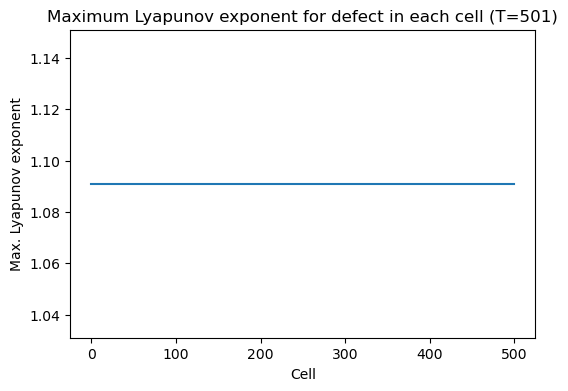

In [24]:
# number of cells
N = 501
rule = 150
states = np.ones(N)
J = jacobian_ECA(rule=rule, states=states, return_next=False)

# initial defect sphere
Y0 = np.diag(np.ones(N))

T = N
ts = np.arange(1,T)

Yt = Y0.copy()
for t in ts:
    print(f"t={t}", end='\r')
    # update Yt
    Yt = J.dot(Yt)
    # build in safety to avoid overflow
    if (np.isnan(Yt).any()) or not (np.isfinite(Yt).any()):
        raise Exception("Overflow!")
    
max_defects = np.max(Yt, axis=0)
max_lyapunovs = np.log(max_defects) / t

fig, ax = plt.subplots(1,1,figsize=(6,4))
ax.plot(max_lyapunovs)
ax.set_title(f"Maximum Lyapunov exponent for defect in each cell (T={T})")
ax.set_ylabel("Max. Lyapunov exponent")
ax.set_xlabel("Cell")

Clearly this is a very boring plot: the maximum Lyapunov exponent is independent of the cell in which the defect is introduced. This is expected, because all cells are equal (due to the uniformity of the ECA), and because rule 150 is additive (the Jacobian is independent of the position in phase space).

# The Lyapunov spectrum

In the third interpretation, we consider the (simultaneous) evolution of all possible single-cell defects by tracing the singular values of $Y^t$. We can calculate the expected value analytically first.

Note that the Jacobian for rule $150$ does not depend on the actual configuration of the ECA. This fact implies that the Jacobian is a so-called [circulant matrix](https://en.wikipedia.org/wiki/Circulant_matrix), which is of the general shape
$$
\mathbf{C} = \begin{pmatrix}
c_0 & c_{N-1} & c_{N-2} & \ldots & c_3 & c_2 & c_1 \\
c_1 & c_0 & c_{N-1} & \ldots & c_4 & c_3 & c_2 \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
c_{N-2} & c_{N-3} & c_{N-4} & \ldots & c_1 & c_0 & c_{N-1} \\
c_{N-1} & c_{N-2} & c_{N-3} & \ldots & c_2 & c_1 & c_0
\end{pmatrix}.
$$
Specifically, for $\mathbf{J}$, $c_0 = c_1 = c_{N-1} = 1$ and all other values are $0$. Now, from Wikipedia:
>Multiplication with a circulant matrix implements a convolution. In Fourier space, convolutions become multiplication. Hence the product of a circulant matrix with a Fourier mode yields a multiple of that Fourier mode, i.e. it is an eigenvector.

The corresponding eigenvalues are therefore
$$
\lambda_k = c_0 + c_1 \exp\left(\frac{1\cdot 2k\pi i}{N}\right) + c_2 \exp\left(\frac{2\cdot k\pi i}{N}\right) + \ldots + c_{N-1} \exp\left(\frac{(N-1)2k\pi}{N}\right),
$$
which for rule $150$ we can simplify to
$$
\lambda_k = 1 + 2\cos\left(\frac{2k\pi}{N}\right).
$$
The singular values of $\mathbf{J}$ are $\sigma_k = |\lambda_k|$, because $\mathbf{J}$ is symmetric.

Now, we have the following general relationship for eigenvalues:
$$
\mathbf{A}\mathbf{v} = \lambda \mathbf{v} \implies \mathbf{A}^t \mathbf{v} = \lambda^t\mathbf{v}
$$
for $t$ a natural number. In words: if $\lambda$ is an eigenvalue of $\mathbf{A}$, then $\lambda^t$ is an eigenvalue of $\mathbf{A}^t$. Therefore the limit of the Lyapunov exponent simplifies considerably:
$$
\Lambda_k = \limsup_{t\rightarrow\infty}\frac{1}{t}{\ln\sigma_k^t} = \ln\sigma_k = \ln\left|1 + 2\cos\left(\frac{2k\pi}{N}\right)\right|.
$$
for $k \in \{0, \ldots, N-1\}$. This indeed has a maximum of $\ln 3$, and checks out when comparing theory with calculations.}

Text(0.5, 0.98, "Comparison of singular values from formula vs. from numpy. They're the same.")

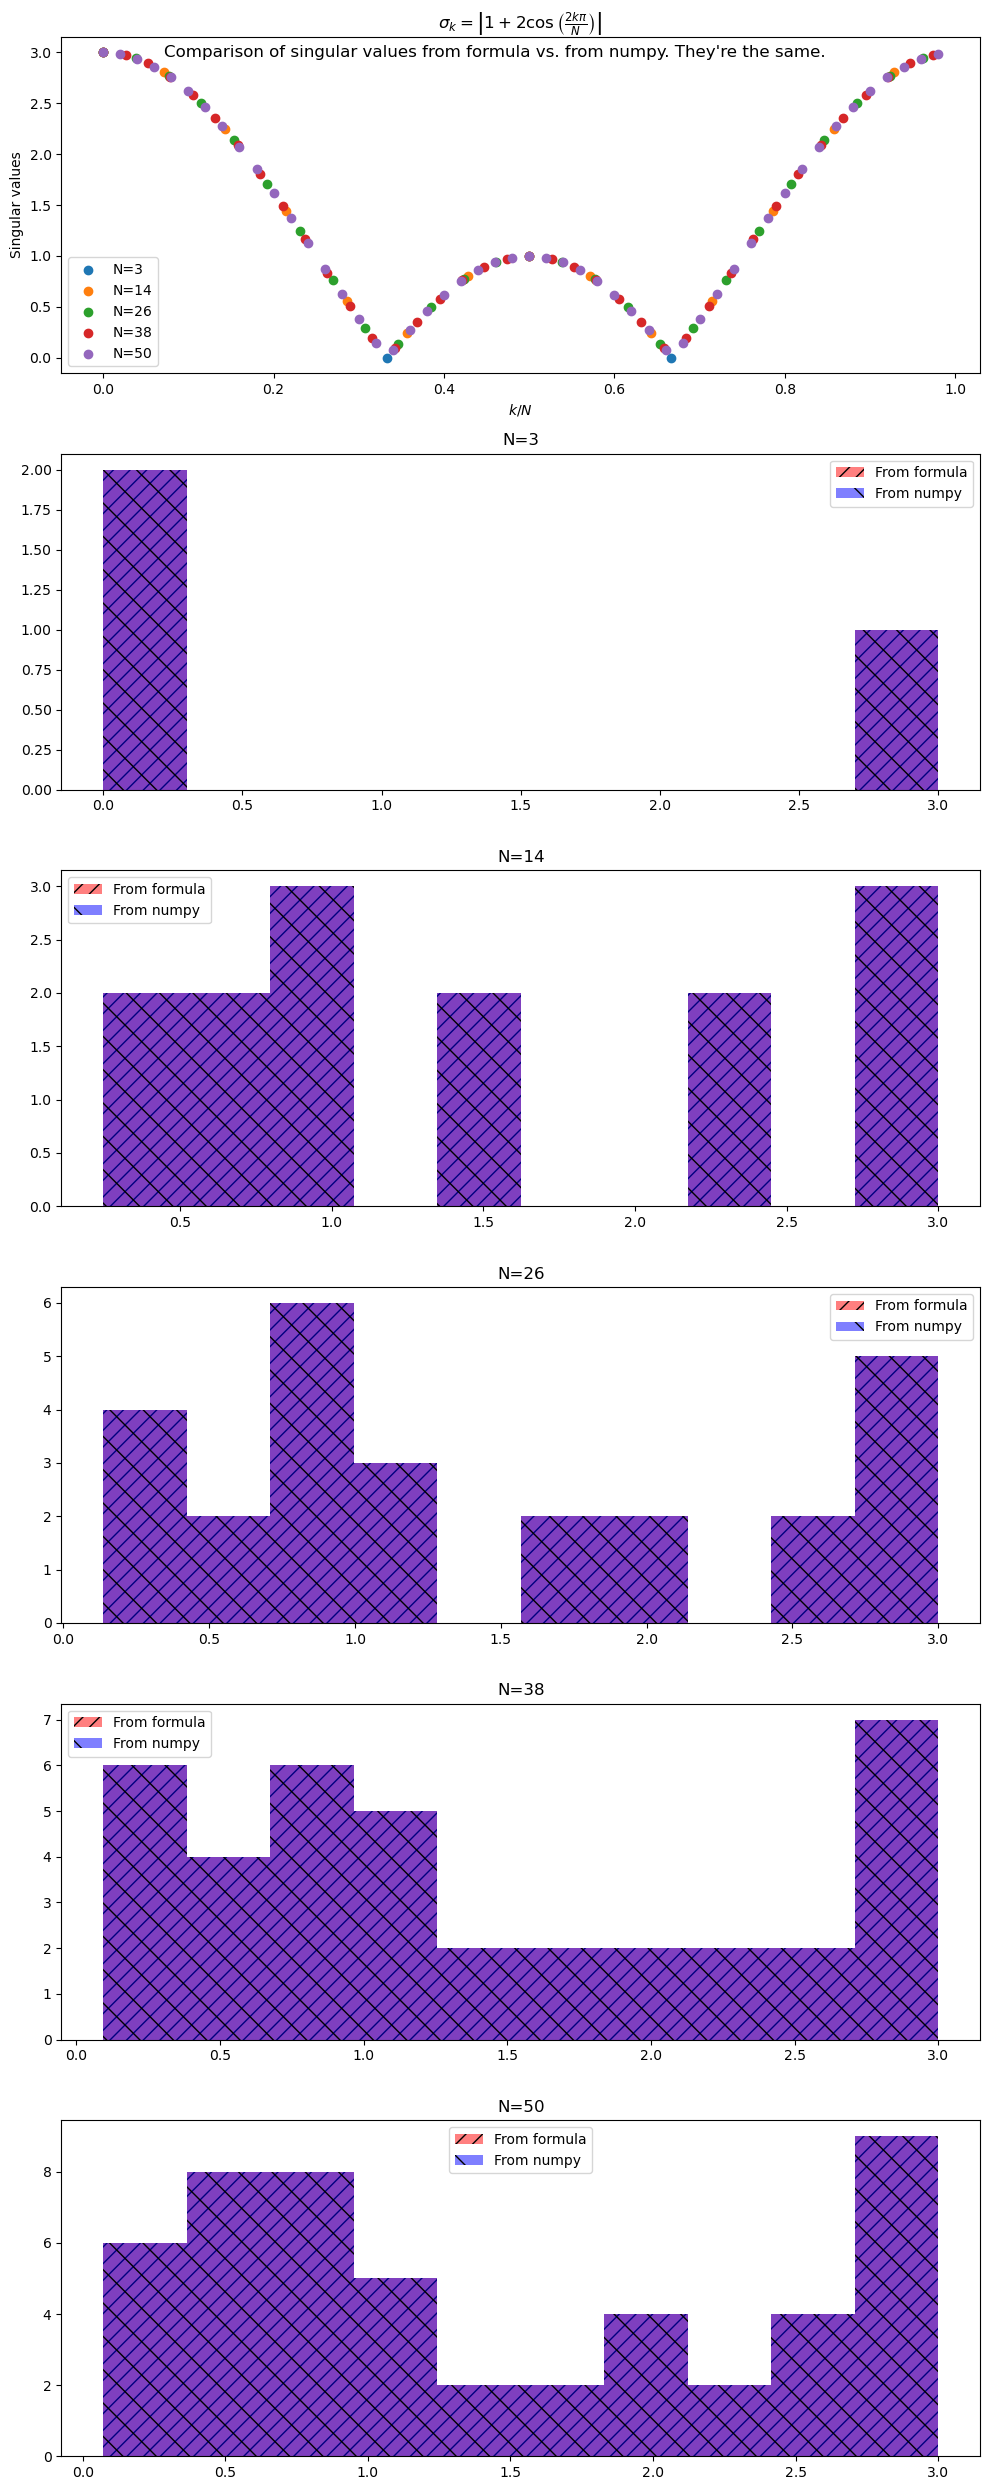

In [41]:
# calculate singular values analytically considering that this is a circulant matrix
def svd_rule150(k,N):
    # k is the index of the singular value
    # N is the number of cells in the ECA
    # note that we can analytically find the singular values of all circulant Jacobians (also non-symmetric ones because then JJ^T is circulant and we can take the square root)
    return np.abs(1 + 2*np.cos(2*k*np.pi/N))

rule = 150

# show some cases
N_of_tests = 5
fig, axs = plt.subplots(N_of_tests+1,1,figsize=(10,25))
init_test = 3
end_test = 50
for i, N in enumerate(np.linspace(init_test,end_test, N_of_tests).astype(int)):
    ks = np.arange(N).astype(int)
    svds_formula = svd_rule150(ks, N)
    states = np.ones(N) # arbitrary for the rules we inspect, but length should change
    J = jacobian_ECA(rule=rule, states=states, return_next=False)
    svds_numpy = np.linalg.svd(J, compute_uv=False)
    axs[0].scatter(ks/N, svds_formula, label=f"N={N}")
    axs[i+1].hist(svds_formula, color='r', hatch='//', alpha=.5, label='From formula')
    axs[i+1].hist(svds_numpy, color='b', hatch='\\', alpha=.5, label='From numpy')
    axs[i+1].set_title(f"N={N}")
    axs[i+1].legend()

axs[0].set_title(r"$\sigma_k = \left|1 + 2\cos\left(\frac{2k\pi}{N}\right)\right|$")
axs[0].legend()
axs[0].set_xlabel(f"$k/N$")
axs[0].set_ylabel(f"Singular values")

fig.tight_layout()
fig.suptitle(f"Comparison of singular values from formula vs. from numpy. They're the same.")

So that checks out. Now to the problem ...

According to the analytical steps laid out above, the Lyapunov spectrum of rule $150$ should only depend on the size of CA, and can easily be calculated from a single Jacobian. For Jacobians that are not symmetric, and especially for Jacobians that _do_ depend on the configuration $\mathbf{s}$ at some time step $t$, this "shortcut" is not possible. In those cases, the Lyapunov spectrum should be calculated by finding the singular values of a "tower of Jacobians"
$$
\left(\prod_{\tau=0}^{t-1}  \mathbf{J}(\mathbf{s}^{t-\tau}) \right),
$$
which will generally (1) take quite some computation, and (2) result in a matrix with very large elements. Recall: for rule $150$ this product is simply the $t$'th power of the constant matrix $\mathbf{J}$.

-----
Now, the **ISSUE** is that we could also calculate the "tower of Jacobians" for rule $150$ and take its singular values. The resulting singular values should of course correspond to those found in the analytical way by means of the discrete Fourier transform. This appears to be the case for small values of $N$ and $t$, but it starts to diverge after a while. More precisely, the computed Lyapunov spectrum starts to shrink after a while, which is in direct conflict with the fact that $\mathbf{A}\mathbf{v} = \lambda\mathbf{v} \implies \mathbf{A}^t\mathbf{v} = \lambda^t\mathbf{v}$.

---

Let's first demonstrate this.

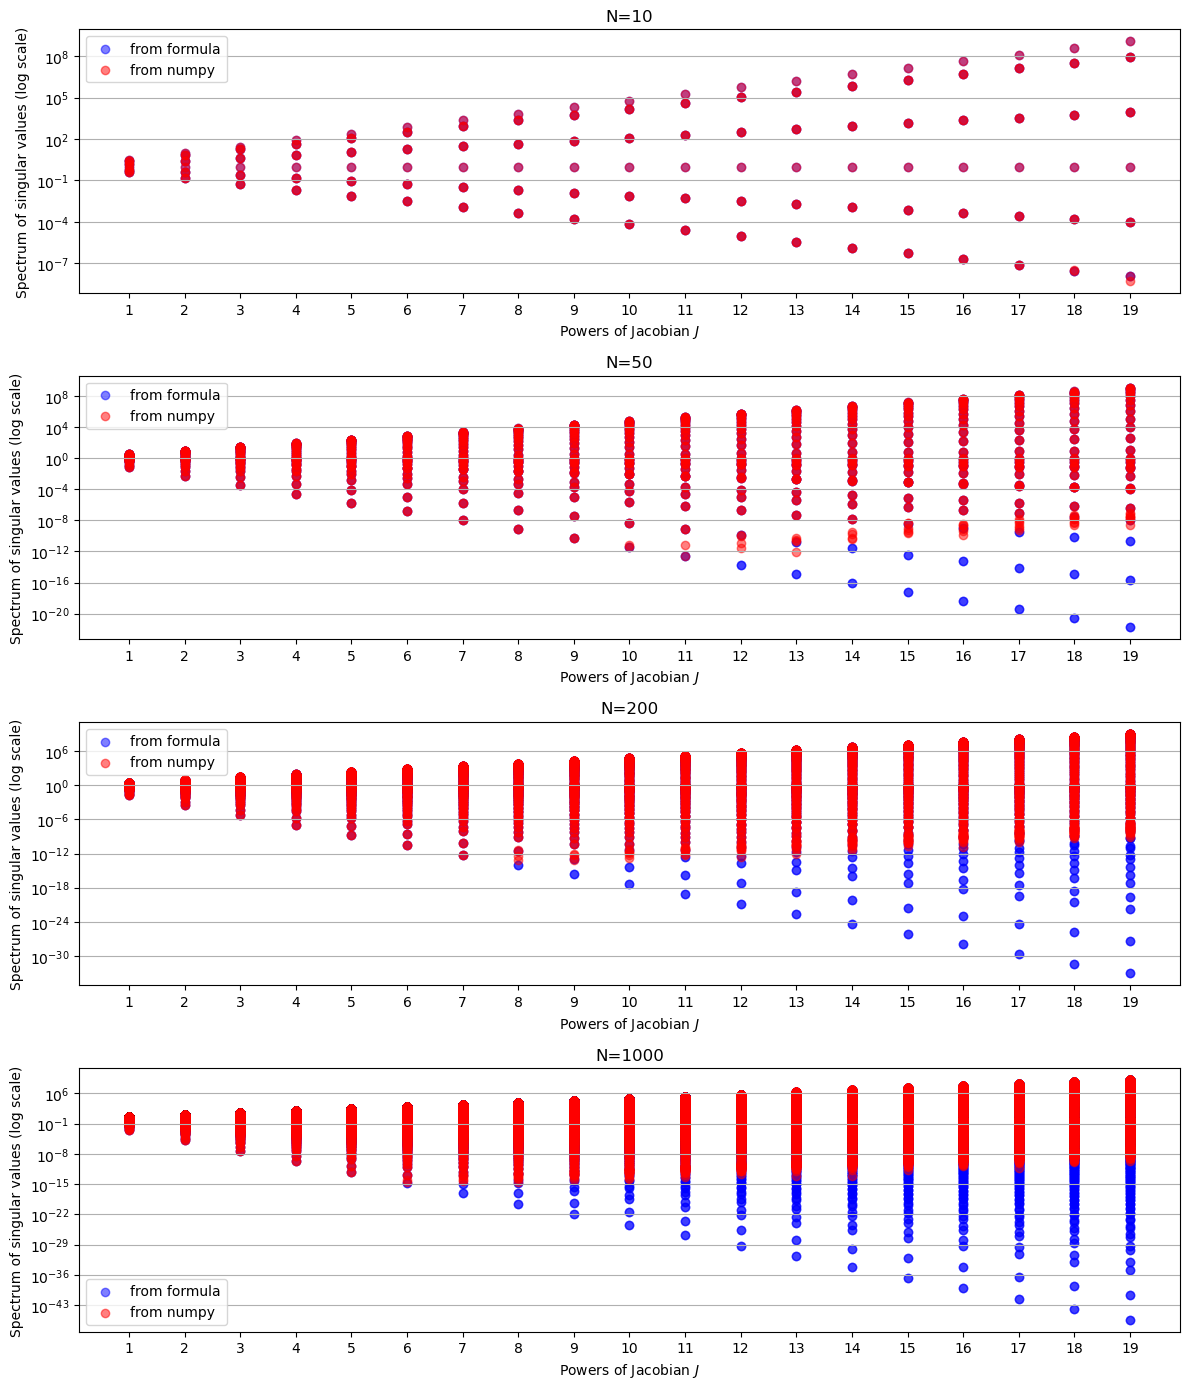

In [30]:
# various CA sizes and various powers (t)
Ns = np.array([10, 50, 200, 1000])
powers = np.arange(1, 20)

rule = 150

# open figure
fig, axs = plt.subplots(len(Ns),1,figsize=(12,14))

for N, ax in zip(Ns, axs):
    ks = np.arange(0, N)
    # main diagonal
    states = np.ones(N) # arbitrary content, but length should change
    J = jacobian_ECA(rule=rule, states=states, return_next=False)
    for power in powers:
        # the analytical solution for the singular values of J^t
        svds_formula = svd_rule150(ks,N)**power
        # the numpy solution for the singular values of J^t
        J_power = np.linalg.matrix_power(J,power)
        svds_numpy = np.linalg.svd(J_power, compute_uv=False)
        if power==powers[0]:
            ax.scatter(power*np.ones_like(ks), svds_formula, color='b', alpha=0.5, label='from formula')
            ax.scatter(power*np.ones_like(ks), svds_numpy, color='r', alpha=0.5, label='from numpy')
        else:
            ax.scatter(power*np.ones_like(ks), svds_formula, color='b', alpha=0.5)
            ax.scatter(power*np.ones_like(ks), svds_numpy, color='r', alpha=0.5)
        ax.set_title(f"N={N}")
        ax.set_yscale('log')
        ax.set_xticks(powers)
        ax.set_xlabel(f"Powers of Jacobian $J$")
        ax.set_ylabel(f"Spectrum of singular values (log scale)")
        ax.legend()
        ax.grid(axis='y')
fig.tight_layout()

Clearly some divergence takes place here for large values of $N$, but also already for relatively modest values for the poweres of $J$. This should not happen, and implies (to me) that numpy is coming up with wrong answers. This clearly poses a **problem when attempting to calculate spectra where no analytical counterpart is available**. This appears to happen around the time when the singular values start being smaller than $10^{-12}$. No problems arise for large singular values (perhaps because they grow less quickly).

Additional proof of something going wrong with these small values is found in the observation that finding the singular values by taking the absolute values of the eigenvalues also results in a slightly different distribution, as shown below.

Text(0.5, 1.0, 'Lyapunov spectrum for rule 150 (N = 1000, power = 20).\nIssues appear to arise for SVDs with tiny values.')

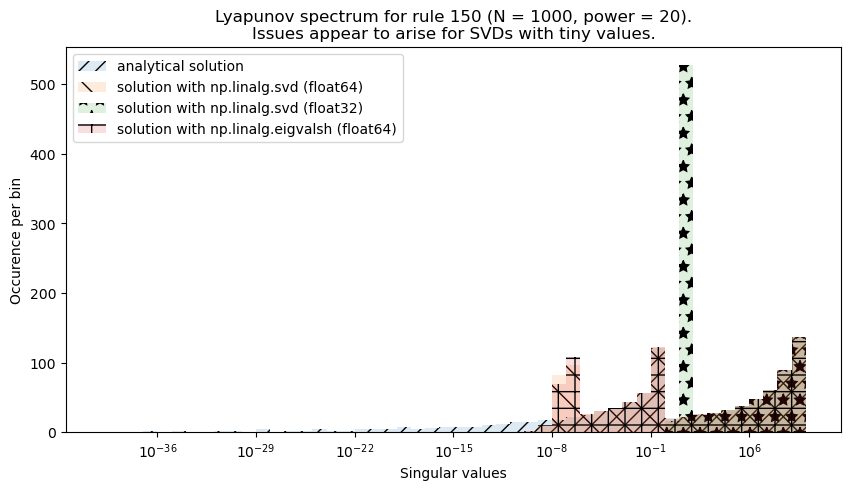

In [38]:
N = 1000
power = 20
ks = np.arange(0, N)

rule = 150
states = np.ones(N)
J = jacobian_ECA(rule=rule, states=states, return_next=False)

J_power = np.linalg.matrix_power(J, power)

J_float32 = J.astype(np.float32)
J_float32_power = np.linalg.matrix_power(J_float32, power)

fro_norm = np.linalg.norm(J, 'fro')
J_scaled_power = np.linalg.matrix_power(J, power) / fro_norm

svds_formula = svd_rule150(ks,N)**power
svds_numpy = np.linalg.svd(J_power, compute_uv=False)
svds_float32 = np.linalg.svd(J_float32_power, compute_uv=False)
svds_gesdd = scipy.linalg.svd(J_power, compute_uv=False, lapack_driver='gesdd')
svds_scaled = np.linalg.svd(J_scaled_power, compute_uv=False) * fro_norm
eigvals_numpy = np.abs(np.linalg.eigvalsh(J_power))

fig, ax = plt.subplots(1,1,figsize=(10,5))
bins=np.logspace(-40, 10, 51, base=10)
alpha=.15
ax.hist(svds_formula, hatch='//', alpha=alpha, bins=bins, label='analytical solution')
ax.hist(svds_numpy, hatch='\\', alpha=alpha,bins=bins, label='solution with np.linalg.svd (float64)')
ax.hist(svds_float32, hatch='*', alpha=alpha, bins=bins, label='solution with np.linalg.svd (float32)')
# ax.hist(svds_gesdd, hatch='o', alpha=alpha, bins=bins, label='solution with scipy (gesdd method)')
# ax.hist(svds_scaled, hatch='O', alpha=alpha, bins=bins, label='solution with numpy (after scaling)')
ax.hist(eigvals_numpy, hatch='+', alpha=alpha,bins=bins, label='solution with np.linalg.eigvalsh (float64)')
ax.set_xscale('log')
ax.legend()
ax.set_xlabel("Singular values")
ax.set_ylabel("Occurence per bin")
ax.set_title(f"Lyapunov spectrum for rule {rule} (N = {N}, power = {power}).\nIssues appear to arise for SVDs with tiny values.")

Cleary, there are some issue here. Note that we used the function `eigvalsh` for Hermitian matrices. If you do not use this, again numerical issues show themselves, as it returns complex numbers, which for our problem is clearly not possible.

---
I think the problem has been sufficiently demonstrated now. Note that this implies that at least some of the reported Lyapunov spectra in at least some of Milan's papers are going to wrong. The question now is how we want to solve this for our project.

---

We can circumvent some of the numerical issues if we are satisfied with information that can be obtained analytically. Some suggestions:
1. Use analytical solutions, e.g. using Python Sympy, or by working in Mathematica. This generally goes quite slowly for networks with many nodes.
2. Upper bound on singular values of the product. If we call $\sigma_1$ the largest singular value, and $\sigma_N$ the smallest, we can use the following relationship:
$$
\sigma_i(\mathbf{A_1} \mathbf{A_2} \cdots \mathbf{A_M}) \leq \sigma_i(\mathbf{A_1})\sigma_1(\mathbf{A_2})\cdots\sigma_1(\mathbf{A_M}).
$$
3. Note: "Products of matrices with very small singular values (near zero) will tend to reduce the rank of $\mathbf{A}$ due to compounding effects on the small singular values, which may approach zero as $M$ increases."

Let's calculate some of these upper bounds

In [37]:
from scipy.sparse.linalg import svds
# minimal values and maximal values of the singular value
def lowerBoundSV(matrices, sv_index = -1):
    """
    Returns the minimum value of the singular value with index 'sv_index' of a product of matrices given in a list
    """
    # argument 'matrices' is a list of matrices
    matrix = matrices[0]
    sv = np.linalg.svd(matrix, compute_uv=False)
    lower_bound = sv[sv_index]
    for matrix in matrices[1:]:
        # find lowest singular value
        # sv = svds(matrix, k=1, which='SM', return_singular_vectors=False) # this is fast but returns different values every time!
        sv = np.linalg.svd(matrix, compute_uv=False)
        sv = sv[-1]
        lower_bound *= sv
    return lower_bound

def upperBoundSV(matrices, sv_index = 0):
    """
    Returns the maximum value of the singular value with index 'sv_index' of a product of matrices given in a list
    """
    # argument 'matrices' is a list of matrices
    matrix = matrices[0]
    sv = np.linalg.svd(matrix, compute_uv=False)
    upper_bound = sv[sv_index]
    for matrix in matrices[1:]:
        # find lowest singular value
        # sv = svds(matrix, k=1, which='SM', return_singular_vectors=False) # this is fast but returns different values every time!
        sv = np.linalg.svd(matrix, compute_uv=False)
        sv = sv[0]
        upper_bound *= sv
    return upper_bound

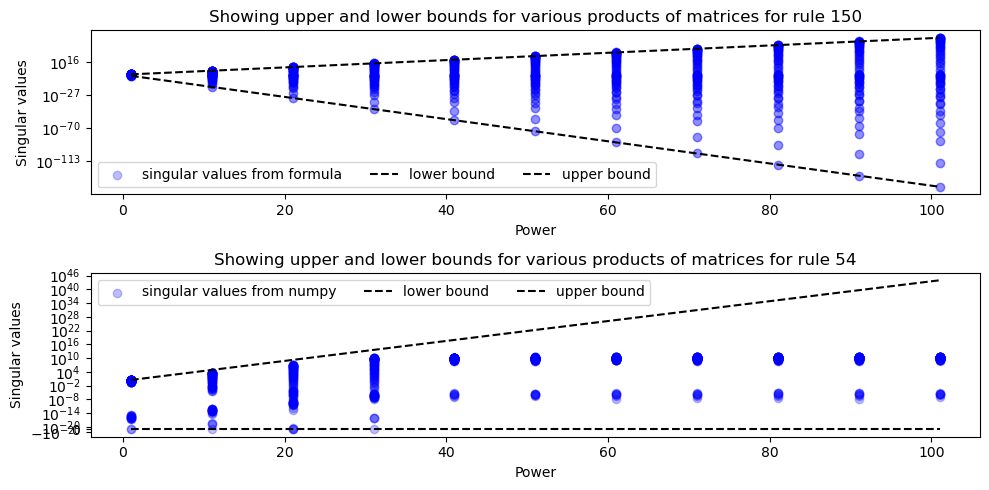

In [97]:
# make a Jacobian
rule = 150
N = 101
ks = np.arange(0, N)
states = np.ones(N) # arbitrary content, but length should change
J = jacobian_ECA(rule=rule, states=states, return_next=False)

fig, axs = plt.subplots(2,1,figsize=(10,5))

# experiment with different powers
powers = np.arange(1,110,10)
lbs = []
ubs = []
for power in powers:
    # stack the Jacobian
    matrices = [J]*power
    # find the bounds and the true values
    lb = lowerBoundSV(matrices)
    ub = upperBoundSV(matrices)
    lbs.append(lb)
    ubs.append(ub)
    # calculate and plot actual singular values
    svds_formula = svd_rule150(ks, N)**power
    if power == powers[0]:
        axs[0].scatter([power]*N, svds_formula, label='singular values from formula', color='blue', alpha=.25)
    else:
        axs[0].scatter([power]*N, svds_formula, color='blue', alpha=.25)

axs[0].plot(powers, lbs, label='lower bound', color='k', ls='--')
axs[0].plot(powers, ubs, label='upper bound', color='k', ls='--')
axs[0].set_yscale('log')
axs[0].legend(loc='lower left', ncols=3)
axs[0].set_title(f"Showing upper and lower bounds for various products of matrices for rule {rule}")
axs[0].set_xlabel("Power")
axs[0].set_ylabel("Singular values")

# similar plot for rule 54 from a ranom initial configuration
rule = 54
states = np.random.randint(2,size=N)
J, newstates = jacobian_ECA(rule=rule, states=np.random.randint(2,size=N), return_next=True)
matrices = [J]
Jprod = J
sv = np.linalg.svd(Jprod, compute_uv=False)
lbs = [lowerBoundSV([J])]
ubs = [upperBoundSV([J])]
axs[1].scatter([powers[0]]*N, sv, label='singular values from numpy', color='blue', alpha=.25)
for (lower_power, upper_power) in zip(powers[0:-1], powers[1:]):
    timejumps = upper_power-lower_power
    for i in range(timejumps):
        J, newstates = jacobian_ECA(rule=rule, states=newstates, return_next=True)
        Jprod = J @ Jprod
        matrices.append(J)
    sv = np.linalg.svd(Jprod, compute_uv=False)
    lbs.append(lowerBoundSV(matrices))
    ubs.append(upperBoundSV(matrices))
    axs[1].scatter([upper_power]*N, sv, color='blue', alpha=.25)

# matrices[]

axs[1].plot(powers, lbs, label='lower bound', color='k', ls='--')
axs[1].plot(powers, ubs, label='upper bound', color='k', ls='--')
axs[1].set_yscale('symlog', linthresh=10**-20)
axs[1].legend(loc='upper left', ncols=3)
axs[1].set_title(f"Showing upper and lower bounds for various products of matrices for rule {rule}")
axs[1].set_xlabel("Power")
axs[1].set_ylabel("Singular values")

plt.tight_layout()

## Calculate all possible analytical solutions for ECA Jacobian singular values

The following non-equivalent ECAs have a constant circulant Jacobian with elements $(c_1, c_0, c_{N-1})$: _(copied from Vichniac 1990)_
- rule $0$: $(0, 0, 0)$
- rule $15$: $(1, 0, 0)$
- rule $51$: $(0, 1, 0)$
- rule $60$: $(1, 1, 0)$
- rule $90$: $(1, 0, 1)$
- rule $105$: $(1, 1, 1)$
- rule $150$: $(1, 1, 1)$
- rule $170$: $(0, 0, 1)$
- rule $204$: $(0, 1, 0)$

Note that we can find the singular values of a circulant matrix by observing that if $\mathbf{C}$ is a circulant matrix, $\mathbf{C}\mathbf{C}^\text{T}$ is a symmetric matrix that is still circulant. After all, if
$$
\mathbf{C} = \begin{pmatrix}
c_0 & c_{N-1} & c_{N-2} & \ldots & c_3 & c_2 & c_1 \\
c_1 & c_0 & c_{N-1} & \ldots & c_4 & c_3 & c_2 \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
c_{N-2} & c_{N-3} & c_{N-4} & \ldots & c_1 & c_0 & c_{N-1} \\
c_{N-1} & c_{N-2} & c_{N-3} & \ldots & c_2 & c_1 & c_0
\end{pmatrix}
\text{ and } \mathbf{C}^\text{T} = \begin{pmatrix}
c_0     & c_1       & c_{2}     & \ldots & c_{N-3}  & c_{N-2}   & c_{N-1} \\
c_{N-1} & c_0       & c_{1}     & \ldots & c_{N-4}  & c_{N-3}   & c_{N-2} \\
\vdots  & \vdots    & \vdots    & \ddots & \vdots   & \vdots    & \vdots \\
c_{2} & c_{3}       & c_{4}     & \ldots & c_{N-1}  & c_{0}     & c_{1} \\
c_{1} & c_{2}       & c_{3}     & \ldots & c_{N-2}  & c_{N-1}   & c_0
\end{pmatrix},
$$
then $\mathbf{C}\mathbf{C}^\text{T} = (\mathbf{C}\mathbf{C}^\text{T})^\text{T}$ with elements
$$
(\mathbf{C}\mathbf{C}^\text{T})_{i,j} = cc_{i,j} = \prod_{k=0}^{N-1} c_{k+i-1} c_{k+j-1}
$$
where $i$ ($j$) is the row (column) index of a matrix (running from $1$ to $N$), and all indices are modulo $N$. This is clearly symmetric due to commutativity of the product. It is circulant as well, because
$$
cc_{i,j} = cc_{i+k, j+k}
$$
for any value of $k \in \mathbb{Z}$ because our indices are taken module $N$. In summary, we find
$$
\mathbf{C}\mathbf{C}^\text{T} = \begin{pmatrix}
cc_0 & cc_{N-1} & cc_{N-2} & \ldots & cc_3 & cc_2 & cc_1 \\
cc_1 & cc_0 & cc_{N-1} & \ldots & cc_4 & cc_3 & cc_2 \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
cc_{N-2} & cc_{N-3} & cc_{N-4} & \ldots & cc_1 & cc_0 & cc_{N-1} \\
cc_{N-1} & cc_{N-2} & cc_{N-3} & \ldots & cc_2 & cc_1 & cc_0
\end{pmatrix}
$$
with ${cc}_k = {cc}_{k+1,1} = \prod_{l=0}^{N-1} c_{l+k} c_{l}$, again with indices modulo $N$.

>**TO DO** switching between indices that start at $0$ and those that start at $1$ is really confusing. I need to standardise this. I just followed the notation convention from Wikipedia, but that's not really convenient.

The singular values of a circulant matrix are therefore simply the square roots of the eigenvalues of the symmetrised circulant matrix. In other words:
$$
(\sigma_k)^2 = cc_0 + {cc}_1 \exp\left(\frac{1\cdot 2k\pi i}{N}\right) + {cc}_2 \exp\left(\frac{2\cdot k\pi i}{N}\right) + \ldots + {cc}_{N-1} \exp\left(\frac{(N-1)2k\pi}{N}\right),
$$

<!-- $$
\mathbf{C}\mathbf{C}^\text{T} = (\mathbf{C}\mathbf{C}^\text{T})^\text{T} = \prod_{i=0}^{N-1}\begin{pmatrix}
c_i^2       & c_i c_{i-1}   & c_i c_{i-2}   & \ldots & c_i c_{i-N+3}    & c_i c_{i-N+2}     & c_i c_{i-N+1} \\
c_{i+1} c_{i} & c_i^2         &         & \ldots & c_4              & c_3               & c_2 \\
\vdots      & \vdots        & \vdots        & \ddots & \vdots           & \vdots            & \vdots \\
c_i c_{i-N+2} & c_{N-3} & c_{N-4} & \ldots & c_1 & c_i^2 & c_{N-1} \\
c_i c_{i-N+1} & c_{N-2} & c_{N-3} & \ldots & c_2 & c_1 & c_i^2
\end{pmatrix},
$$
where the big product operates element-wise and all indices are modulo $(N-1)$ -->

In [ ]:
def svds_from_circulant(first_column):
    """
    test
    """
    